In [1]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features_machine_and_movement_complete.csv", target_path="../../../../data/ml/targets_movement_complete.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
X = rf_preprocessor.group_and_pad(rf_preprocessor.sensor_df, group_col="Experiment_ID")
Y = rf_preprocessor.group_and_pad(rf_preprocessor.target_df, group_col="Experiment_ID")[:,:,1:-1]
X_rf, Y_rf = rf_preprocessor.prepare_rf_data(X, Y)

In [2]:
from utils.random_forest_utils.model import RandomForestTrainer
trainer = RandomForestTrainer()

In [3]:
trainer.train(X_rf, Y_rf)
trainer.save_model("../../../../models/rf/rf_movement_machine.joblib")

Training complete. Model OOB score: 0.8362260585145371


In [4]:
rf = trainer.load_model("../../../../models/rf/rf_movement_machine.joblib")

Model loaded from ../../../../models/rf/rf_movement_machine.joblib


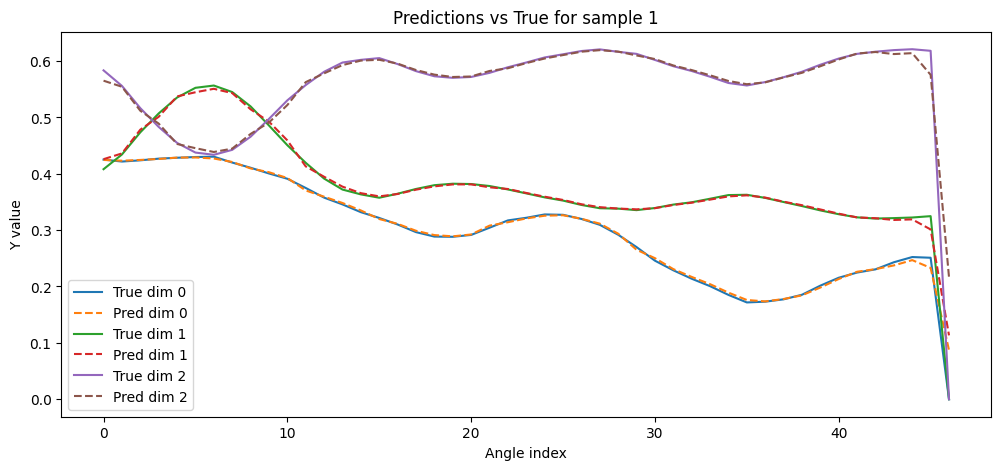

In [5]:
trainer.predict_by_experiment_angle(sample_idx=1, X=X, Y=Y)

In [6]:
from utils.random_forest_utils.window_importance_utils import WindowImportance

wi = WindowImportance(
    rf,
    num_features=X.shape[2],
    sensors_path="../../../../data/ml/features_machine_and_movement_complete.csv",
    target_path="../../../../data/ml/targets_movement_complete.csv",
)
wi.interactive_window_plot()


interactive(children=(SelectionSlider(description='Experiment ID', options=(2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12…